<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html Firstmidterm2022.do.txt --no_mako -->
<!-- dom:TITLE: PHY321: Classical Mechanics 1 -->

In [2]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
plt.style.use('seaborn-v0_8-colorblind')

## Exercise 3, Model your own system (30 points)

In this problem, you will choose a one dimensional system of your own. You may choose a known potential, or you may invent your own. Your potential must:

1. Have at least one stable equilibrium point.
2. Have at least one unstable equilibrium point, or some other interesting feature (e.g., asymptotic behavior).
3. For some choice of total energy, it should have oscillatory motion (i.e., classical turning points).
4. Produce a non-linear and conservative force.
5. Be continuous and differentiable over the range of interest.

For this problem, you will need to perform the following tasks:

* **3a. (5 pts)** Write down the potential and start to demonstrate that it meets the above criteria. **Make sure it is conservative and that the force is nonlinear before proceeding.**
* **3b. (5 pts)** Sketch or plot the potential and find the equilibrium points. You need to show you can compute the equilibrium points and characterize their stability. For some choices of potential, you may need to use a numerical method to find the equilibrium points and conceptual arguments to determine their stability.
* **3c. (5 pts)** Pick a total energy that gives rise to oscillatory motion. Show this by sketching or plotting the energy diagram and describing the motion. Are there any other kinds of motion that can occur for other choices of total energy?
* **3d. (10 pts)** Write a numerical algorithm to find the position and velocity of the particle (it's trajectories) for the choice of total energy where the motion is oscillatory. Here you must use two methods: (1) the standard forward Euler, and either (2) the Euler-Cromer or the [Velocity Verlet](https://en.wikipedia.org/wiki/Verlet_integration) algorithms. You will need to pick the time step $\Delta t$ and the total time $t_{\rm max}$ for your simulation. Compare the results of the two algorithms. Which one is better? Justify your answer. **You might find this [numerical integration resource](../resources/integrators.ipynb) helpful.**
* **3e. (5 pts)** Use your program to plot the energy of the particle (T), the potential energy (V), and the total energy (E) as a function of time. Discuss the behavior of the energy between each choice of algorithm. Is energy conserved in your simulations?

For this part of the assignment is a asymmetrical quartic well ax^4 - bx^2 + cx

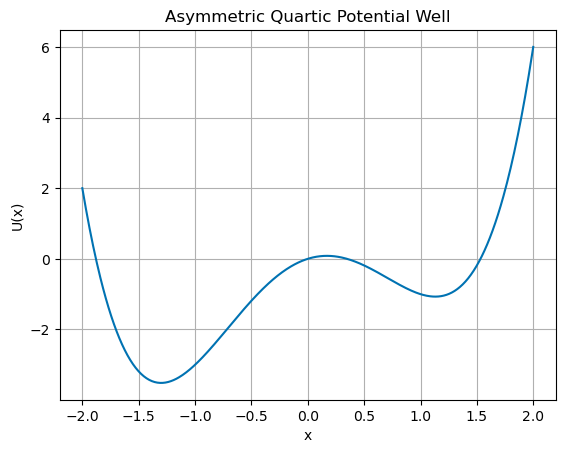

In [ ]:
#3a
#Graphing function to show it fitting criteria provided above

#Setting parameters (subject to change)
a = 1.0
b = 3.0
c = 1.0

#define potential function U
def U(x):
    return a*x**4 - b*x**2 + c*x

#define force function F
#F = -dU/dx
def F(x):
    return -4*a*x**3 + 2*b*x - c

#create x range for function
x = np.linspace(-2, 2, 500)

#plot function
plt.figure()
plt.plot(x, U(x))
plt.xlabel('x')
plt.ylabel('U(x)')
plt.title('Asymmetric Quartic Potential Well')
plt.grid()
plt.show()

This graph clearly shows at 1 unstable equilibrium point and 2 stable equilibrium point. The graph also shows oscillatory motion (turning points) and is continuous and differentiable. Since the graph is differentiable and continuous and F = -dU/dx, there is a non-linear, conservative force over this whole potential function.

In [4]:
#3b
#Finding equilibria, determining stability, and replotting with equilibria

#Coefficients of our force function 4ax^3 - 2bx + c = 0
coeff = [4*a, 0, -2*b, c]

equilibria = np.roots(coeff)

print("Equilibrium points : x=", equilibria)

#Define stability (second derivative) function
def d2u(x):
    return 12*a*x**2 - 2*b

#Determine stable (+d2u) or unstable (-d2u)
for i in equilibria:
    if d2u(i) > 0:
        print(i, 'is a stable equilibrium point')
    else:
        print(i, 'is an unstable equilibrium point')

Equilibrium points : x= [-1.30083957  1.13090112  0.16993844]
-1.3008395659415783 is a stable equilibrium point
1.1309011226299872 is a stable equilibrium point
0.16993844331159125 is an unstable equilibrium point


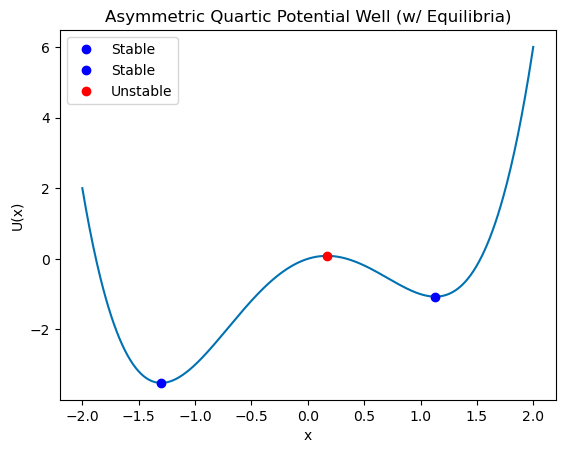

In [5]:
#Replotting with equilibria
plt.plot(x, U(x))

#Plot stable points and unstable points different colors
for i in equilibria:
    if d2u(i) > 0:
        plt.plot(i, U(i), 'bo', label='Stable')
    else:
        plt.plot(i, U(i), 'ro', label="Unstable")

#Replot graph
plt.xlabel("x")
plt.ylabel('U(x)')
plt.title('Asymmetric Quartic Potential Well (w/ Equilibria)')
plt.legend()
plt.show()

#This graph shows blue points as stable and red points as unstable in the same spots we calculated earlier

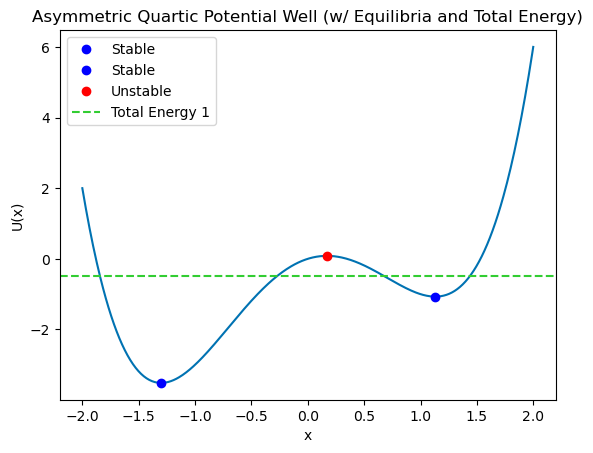

In [ ]:
#3c Choosing total energy and explaining oscillatory motion

#Plot previous graph
plt.plot(x, U(x))

for i in equilibria:
    if d2u(i) > 0:
        plt.plot(i, U(i), 'bo', label='Stable')
    else:
        plt.plot(i, U(i), 'ro', label="Unstable")

plt.xlabel("x")
plt.ylabel('U(x)')
plt.title('Asymmetric Quartic Potential Well (w/ Equilibria and Total Energy)')

#Create and plot energy line
E = -0.5 #Between minimum and maximum energy
plt.axhline(E, linestyle='--', color='limegreen', label='Total Energy 1')

plt.legend()
plt.show()

A graph with total energy E= -0.5J shows oscillatory motion in the left well and right well. Since the "particle" is confined by two turning points, it replicates oscillatory motion inside the respective well. Both wells display this behavior. At both stable equilibria, the "particle" is at rest. As the unstable equilibria, the "particle" will fall into one of the wells to achieve stability

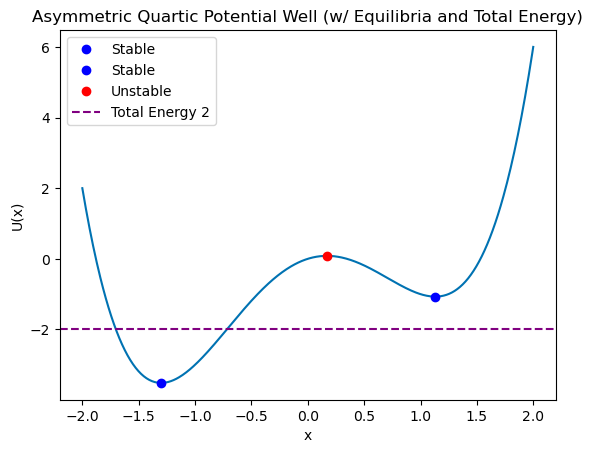

In [ ]:
#3c Continued

#Plot previous graph again
plt.plot(x, U(x))

for i in equilibria:
    if d2u(i) > 0:
        plt.plot(i, U(i), 'bo', label='Stable')
    else:
        plt.plot(i, U(i), 'ro', label="Unstable")

plt.xlabel("x")
plt.ylabel('U(x)')
plt.title('Asymmetric Quartic Potential Well (w/ Equilibria and Total Energy)')

#Create and plot another energy line
E = -2.0 #Below right well, but above left well
plt.axhline(E, linestyle='--', color='purple', label='Total Energy 2')

plt.legend()
plt.show()

Viewing this graph, the total energy is below the right well and above the left well. This means that the "particle" cannot exist in the right well as there is not enough energy in the system to satisfy a stable point. Knowing this, oscillatory motion is only possibel in the left well when total energy E = -2.0J

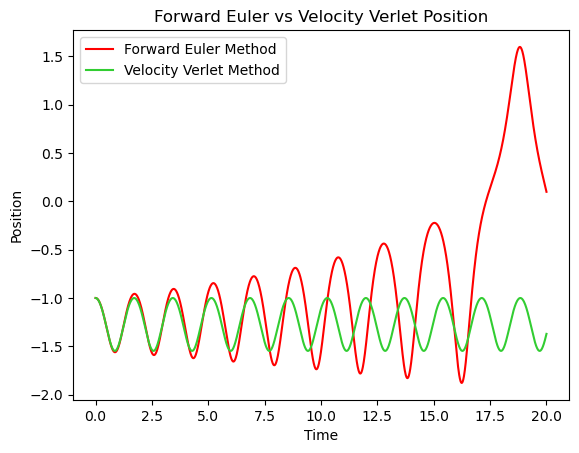

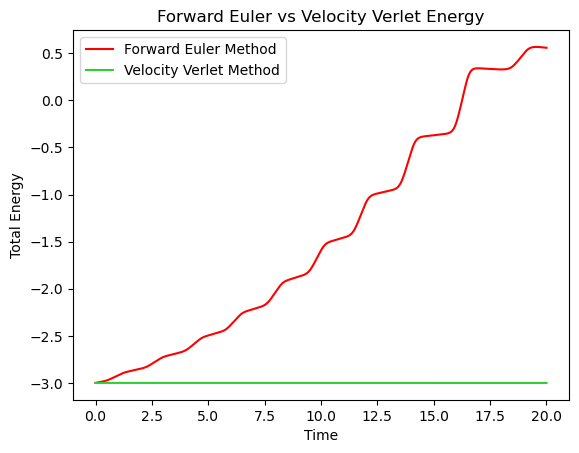

In [10]:
#3d Writing Numerical Algorithm and Testing Euler and Verlet Algorithms

#Choose initial values

a = 1.0
b = 3.0
c = 1.0

m = 1.0
dt = 0.01
t_max = 20
N = int(T/dt)

x0 = -1.0
v0 = 0.0

#Initialize Energy Functin
def energy(x, v):
    return 0.5*m*v**2 + a*x**4 - b*x**2 + c*x

#METHOD 1 : FORWARD EULER
x_euler = np.zeros(N)
v_euler = np.zeros(N)

x_euler[0] = x0
v_euler[0] = v0

#Euler step loop
for i in range(N-1):
    x_euler[i+1] = x_euler[i] + v_euler[i]*dt
    v_euler[i+1] = v_euler[i] + F(x_euler[i])*dt

#METHOD 2 : EULER-CROMER / VELOCITY VERLET
x_verlet = np.zeros(N)
v_verlet = np.zeros(N)

x_verlet[0] = x0
v_verlet[0] = v0

#Verlet method loop
for i in range(N-1):
    a_n = F(x_verlet[i])/m 
    
    x_verlet[i+1] = x_verlet[i] + v_verlet[i]*dt + 0.5*a_n*dt**2

    a_n1 = F(x_verlet[i+1])/m 

    v_verlet[i+1] = v_verlet[i] + 0.5*(a_n + a_n1)*dt

#Comparison Plot
t = np.linspace(0, t_max, N)

plt.figure()
plt.plot(t, x_euler, label = 'Forward Euler Method', color = 'red')
plt.plot(t, x_verlet, label = 'Velocity Verlet Method', color = 'limegreen')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Forward Euler vs Velocity Verlet Position')
plt.legend()
plt.show()

#Energy Graph Comparison
E_euler = energy(x_euler, v_euler)
E_verlet = energy(x_verlet, v_verlet)

plt.figure()
plt.plot(t, E_euler, label = 'Forward Euler Method', color = 'red')
plt.plot(t, E_verlet, label = 'Velocity Verlet Method', color = 'limegreen')
plt.xlabel('Time')
plt.ylabel('Total Energy')
plt.title('Forward Euler vs Velocity Verlet Energy')
plt.legend()
plt.show()

As we can see in the position graph, the forward euler method oscillates and rapidly grows in amplitude while the velocity verlet method stays consistent. We can also see that the forward euler method starts to go a little crazy toward the end of the simulation. In the energy graph, we can see that the forward euler method's total energy increases throughout the simulation, while the velocity verlet method's remains constant. These facts show that the velocity verlet method provides a more accurate and reliable simulation since energy should always be conserved in an oscillatory motion simulation like this.

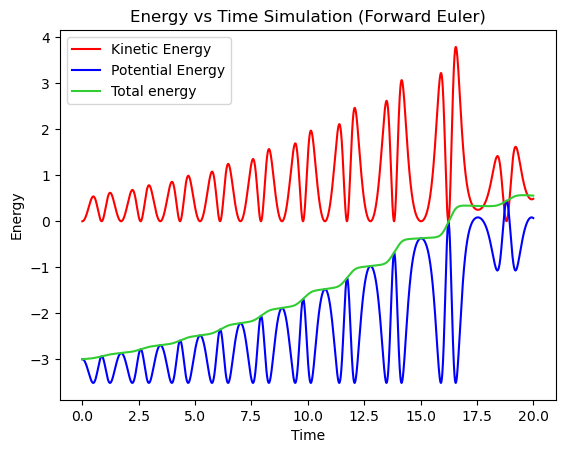

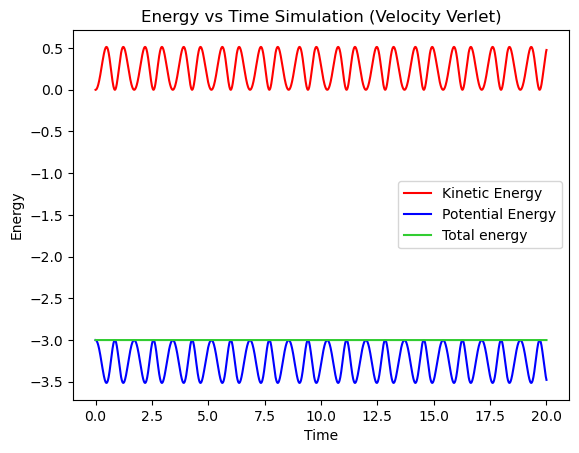

In [18]:
#3e Simulation of Energy on Particle (T) with Potential (V)

#Create energy simulation for Forward Euler method
T_euler = 0.5 * m * v_euler**2
V_euler = a*x_euler**4 - b*x_euler**2 + c*x_euler
E_euler_sim = T_euler + V_euler

#Create energy simulation for Velocity Verlet method
T_verlet = 0.5 * m * v_verlet**2
V_verlet = a*x_verlet**4 - b*x_verlet**2 + c*x_verlet
E_verlet_sim = T_verlet + V_verlet

#Plot simulations
#Forward Euler
plt.figure()
plt.plot(t, T_euler, label='Kinetic Energy', color = 'red')
plt.plot(t, V_euler, label='Potential Energy', color='blue')
plt.plot(t, E_euler_sim, label="Total energy", color='limegreen')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Energy vs Time Simulation (Forward Euler)')
plt.legend()
plt.show()

#Velocity Verlet
plt.figure()
plt.plot(t, T_verlet, label='Kinetic Energy', color='red')
plt.plot(t, V_verlet, label='Potential Energy',color='blue')
plt.plot(t, E_verlet_sim, label="Total energy",color='limegreen')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Energy vs Time Simulation (Velocity Verlet)')
plt.legend()
plt.show()


In the forward euler method, energy is not conserved throughout the simulation. As we can see in the lime green line, the energy slowly rises along with the potential and kinetic peaks. This shows that this form of simulation is not the most accurate.

In the velocity verlet method, energy is conserved throughout. This can be seen in the lime green line as the slope is zero. Also, the peaks and troughs of the kinetic and potential energies are uniform throughout the simulation. This shows that this form of simulation is a more stable and accurate simulation method.